In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression


In [2]:
df=pd.read_csv('UK_Accident.csv')

In [3]:
df.head()

,Unnamed: 0,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,...,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Year
0,0,200501BS00001,525680.0,178240.0,-0.191170,51.489096,1,2,1,1,...,Zebra crossing,Daylight: Street light present,Raining without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002849,2005
1,1,200501BS00002,524170.0,181650.0,-0.211708,51.520075,1,3,1,1,...,Pedestrian phase at traffic signal junction,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002909,2005
2,2,200501BS00003,524520.0,182240.0,-0.206458,51.525301,1,3,2,1,...,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002857,2005
3,3,200501BS00004,526900.0,177530.0,-0.173862,51.482442,1,3,1,1,...,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002840,2005
4,4,200501BS00005,528060.0,179040.0,-0.156618,51.495752,1,3,1,1,...,No physical crossing within 50 meters,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002863,2005


In [4]:
df.isnull().sum().sum()

np.int64(3655911)

In [5]:
df.columns

Index(['Unnamed: 0', 'Accident_Index', 'Location_Easting_OSGR',
       'Location_Northing_OSGR', 'Longitude', 'Latitude', 'Police_Force',
       'Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties',
       'Date', 'Day_of_Week', 'Time', 'Local_Authority_(District)',
       'Local_Authority_(Highway)', '1st_Road_Class', '1st_Road_Number',
       'Road_Type', 'Speed_limit', 'Junction_Control', '2nd_Road_Class',
       '2nd_Road_Number', 'Pedestrian_Crossing-Human_Control',
       'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions',
       'Weather_Conditions', 'Road_Surface_Conditions',
       'Special_Conditions_at_Site', 'Carriageway_Hazards',
       'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident',
       'LSOA_of_Accident_Location', 'Year'],
      dtype='str')

In [6]:
df.drop([ 'Unnamed: 0',
    'Accident_Index',
    'Location_Easting_OSGR',
    'Location_Northing_OSGR',
    'LSOA_of_Accident_Location',
    'Local_Authority_(Highway)'],axis=1,inplace=True)

In [7]:
df.head()

,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,Day_of_Week,Time,Local_Authority_(District),...,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,Year
0,-0.191170,51.489096,1,2,1,1,04/01/2005,3,17:42,12,...,None within 50 metres,Zebra crossing,Daylight: Street light present,Raining without high winds,Wet/Damp,NaN,NaN,1,Yes,2005
1,-0.211708,51.520075,1,3,1,1,05/01/2005,4,17:36,12,...,None within 50 metres,Pedestrian phase at traffic signal junction,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,2005
2,-0.206458,51.525301,1,3,2,1,06/01/2005,5,00:15,12,...,None within 50 metres,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,2005
3,-0.173862,51.482442,1,3,1,1,07/01/2005,6,10:35,12,...,None within 50 metres,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1,Yes,2005
4,-0.156618,51.495752,1,3,1,1,10/01/2005,2,21:13,12,...,None within 50 metres,No physical crossing within 50 meters,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,NaN,NaN,1,Yes,2005


In [8]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

In [9]:
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Year'] = df['Date'].dt.year

In [10]:
df.drop(['Date', 'Time'], axis=1, inplace=True)

In [11]:
df['Carriageway_Hazards'].isnull().sum()

np.int64(1476900)

In [12]:
df.drop('Number_of_Casualties',axis=1,inplace=True)

In [13]:
df.head()

,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Road_Type,...,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,Year,Month,Day
0,-0.191170,51.489096,1,2,1,3,12,3,3218,Single carriageway,...,Daylight: Street light present,Raining without high winds,Wet/Damp,NaN,NaN,1,Yes,2005,1,4
1,-0.211708,51.520075,1,3,1,4,12,4,450,Dual carriageway,...,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,2005,1,5
2,-0.206458,51.525301,1,3,2,5,12,5,0,Single carriageway,...,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,2005,1,6
3,-0.173862,51.482442,1,3,1,6,12,3,3220,Single carriageway,...,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1,Yes,2005,1,7
4,-0.156618,51.495752,1,3,1,2,12,6,0,Single carriageway,...,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,NaN,NaN,1,Yes,2005,1,10


In [14]:
df['Road_Type'].value_counts()
df['Road_Type'].isnull().sum()


np.int64(0)

In [15]:
df.isnull().sum().sum()

np.int64(3547455)

In [16]:
df['Special_Conditions_at_Site']=df['Special_Conditions_at_Site'].fillna('None')
df['Carriageway_Hazards']=df['Carriageway_Hazards'].fillna('None')

In [17]:
df.isnull().sum()

Longitude                                         101
Latitude                                            0
Police_Force                                        0
Accident_Severity                                   0
Number_of_Vehicles                                  0
Day_of_Week                                         0
Local_Authority_(District)                          0
1st_Road_Class                                      0
1st_Road_Number                                     0
Road_Type                                           0
Speed_limit                                         0
Junction_Control                               602835
2nd_Road_Class                                      0
2nd_Road_Number                                     0
Pedestrian_Crossing-Human_Control                  17
Pedestrian_Crossing-Physical_Facilities            34
Light_Conditions                                    0
Weather_Conditions                                  0
Road_Surface_Conditions     

In [18]:
df.head()

,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Road_Type,...,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,Year,Month,Day
0,-0.191170,51.489096,1,2,1,3,12,3,3218,Single carriageway,...,Daylight: Street light present,Raining without high winds,Wet/Damp,None,None,1,Yes,2005,1,4
1,-0.211708,51.520075,1,3,1,4,12,4,450,Dual carriageway,...,Darkness: Street lights present and lit,Fine without high winds,Dry,None,None,1,Yes,2005,1,5
2,-0.206458,51.525301,1,3,2,5,12,5,0,Single carriageway,...,Darkness: Street lights present and lit,Fine without high winds,Dry,None,None,1,Yes,2005,1,6
3,-0.173862,51.482442,1,3,1,6,12,3,3220,Single carriageway,...,Daylight: Street light present,Fine without high winds,Dry,None,None,1,Yes,2005,1,7
4,-0.156618,51.495752,1,3,1,2,12,6,0,Single carriageway,...,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,None,None,1,Yes,2005,1,10


In [19]:
df['Junction_Control'] = df['Junction_Control'].fillna('None')

In [20]:
df['Pedestrian_Crossing-Human_Control'].value_counts()



Pedestrian_Crossing-Human_Control
None within 50 metres                 1495269
Control by other authorised person       5220
Control by school crossing patrol        3644
Name: count, dtype: int64

In [21]:
df = pd.get_dummies(df, columns=['Pedestrian_Crossing-Human_Control'])

In [22]:
df['Pedestrian_Crossing-Physical_Facilities'].value_counts()


Pedestrian_Crossing-Physical_Facilities
No physical crossing within 50 meters          1252571
Pedestrian phase at traffic signal junction     100248
non-junction pedestrian crossing                 79231
Zebra crossing                                   40106
Central refuge                                   27660
Footbridge or subway                              4300
Name: count, dtype: int64

In [23]:
df = pd.get_dummies(df, columns=['Pedestrian_Crossing-Physical_Facilities'])

In [24]:
df['Light_Conditions'].value_counts()


Light_Conditions
Daylight: Street light present               1102222
Darkness: Street lights present and lit       296340
Darkeness: No street lighting                  82559
Darkness: Street lighting unknown              16120
Darkness: Street lights present but unlit       6909
Name: count, dtype: int64

In [25]:
df['Weather_Conditions'].value_counts()


Weather_Conditions
Fine without high winds       1203943
Raining without high winds     177663
Other                           33503
Unknown                         28422
Raining with high winds         20813
Fine with high winds            18355
Snowing without high winds      11301
Fog or mist                      8190
Snowing with high winds          1960
Name: count, dtype: int64

In [26]:
df['Road_Surface_Conditions'].value_counts()


Road_Surface_Conditions
Dry                          1034670
Wet/Damp                      423477
Frost/Ice                      31405
Snow                           10497
Flood (Over 3cm of water)       2143
Normal                          1958
Name: count, dtype: int64

In [27]:
df['Special_Conditions_at_Site'].value_counts()

Special_Conditions_at_Site
None                                               1467568
Roadworks                                            17223
Ol or diesel                                          5243
Mud                                                   4610
Road surface defective                                3664
Auto traffic singal out                               2788
Permanent sign or marking defective or obscured       2269
Auto traffic signal partly defective                   785
Name: count, dtype: int64

In [28]:
df.isnull().sum()

Longitude                                                                              101
Latitude                                                                                 0
Police_Force                                                                             0
Accident_Severity                                                                        0
Number_of_Vehicles                                                                       0
Day_of_Week                                                                              0
Local_Authority_(District)                                                               0
1st_Road_Class                                                                           0
1st_Road_Number                                                                          0
Road_Type                                                                                0
Speed_limit                                                                              0

In [29]:
df = df.dropna(subset=['Longitude'])

In [30]:
df.isnull().sum()


Longitude                                                                              0
Latitude                                                                               0
Police_Force                                                                           0
Accident_Severity                                                                      0
Number_of_Vehicles                                                                     0
Day_of_Week                                                                            0
Local_Authority_(District)                                                             0
1st_Road_Class                                                                         0
1st_Road_Number                                                                        0
Road_Type                                                                              0
Speed_limit                                                                            0
Junction_Control     

In [31]:
df['Light_Conditions'] = df['Light_Conditions'].replace({
    'Daylight: Street light present': 'Daylight',
    'Darkness: Street lights present and lit': 'Darkness_Lit',
    'Darkness: No street lighting': 'Darkness_No_Light',
    'Darkness: Street lighting unknown': 'Darkness_Unknown',
    'Darkness: Street lights present but unlit': 'Darkness_Unlit'
})

In [32]:
df = pd.get_dummies(df, columns=['Light_Conditions'])

In [33]:
df.head()

,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Road_Type,...,Pedestrian_Crossing-Physical_Facilities_Footbridge or subway,Pedestrian_Crossing-Physical_Facilities_No physical crossing within 50 meters,Pedestrian_Crossing-Physical_Facilities_Pedestrian phase at traffic signal junction,Pedestrian_Crossing-Physical_Facilities_Zebra crossing,Pedestrian_Crossing-Physical_Facilities_non-junction pedestrian crossing,Light_Conditions_Darkeness: No street lighting,Light_Conditions_Darkness_Lit,Light_Conditions_Darkness_Unknown,Light_Conditions_Darkness_Unlit,Light_Conditions_Daylight
0,-0.191170,51.489096,1,2,1,3,12,3,3218,Single carriageway,...,False,False,False,True,False,False,False,False,False,True
1,-0.211708,51.520075,1,3,1,4,12,4,450,Dual carriageway,...,False,False,True,False,False,False,True,False,False,False
2,-0.206458,51.525301,1,3,2,5,12,5,0,Single carriageway,...,False,True,False,False,False,False,True,False,False,False
3,-0.173862,51.482442,1,3,1,6,12,3,3220,Single carriageway,...,False,True,False,False,False,False,False,False,False,True
4,-0.156618,51.495752,1,3,1,2,12,6,0,Single carriageway,...,False,True,False,False,False,False,False,True,False,False


In [34]:
df=pd.get_dummies(df,columns=['Junction_Control'])
df=pd.get_dummies(df,columns=['Weather_Conditions'])
df=pd.get_dummies(df,columns=['Road_Surface_Conditions'])

In [35]:
df.columns

Index(['Longitude', 'Latitude', 'Police_Force', 'Accident_Severity',
       'Number_of_Vehicles', 'Day_of_Week', 'Local_Authority_(District)',
       '1st_Road_Class', '1st_Road_Number', 'Road_Type', 'Speed_limit',
       '2nd_Road_Class', '2nd_Road_Number', 'Special_Conditions_at_Site',
       'Carriageway_Hazards', 'Urban_or_Rural_Area',
       'Did_Police_Officer_Attend_Scene_of_Accident', 'Year', 'Month', 'Day',
       'Pedestrian_Crossing-Human_Control_Control by other authorised person',
       'Pedestrian_Crossing-Human_Control_Control by school crossing patrol',
       'Pedestrian_Crossing-Human_Control_None within 50 metres',
       'Pedestrian_Crossing-Physical_Facilities_Central refuge',
       'Pedestrian_Crossing-Physical_Facilities_Footbridge or subway',
       'Pedestrian_Crossing-Physical_Facilities_No physical crossing within 50 meters',
       'Pedestrian_Crossing-Physical_Facilities_Pedestrian phase at traffic signal junction',
       'Pedestrian_Crossing-Physical_Fa

In [36]:
df.head()

,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Road_Type,...,Weather_Conditions_Raining without high winds,Weather_Conditions_Snowing with high winds,Weather_Conditions_Snowing without high winds,Weather_Conditions_Unknown,Road_Surface_Conditions_Dry,Road_Surface_Conditions_Flood (Over 3cm of water),Road_Surface_Conditions_Frost/Ice,Road_Surface_Conditions_Normal,Road_Surface_Conditions_Snow,Road_Surface_Conditions_Wet/Damp
0,-0.191170,51.489096,1,2,1,3,12,3,3218,Single carriageway,...,True,False,False,False,False,False,False,False,False,True
1,-0.211708,51.520075,1,3,1,4,12,4,450,Dual carriageway,...,False,False,False,False,True,False,False,False,False,False
2,-0.206458,51.525301,1,3,2,5,12,5,0,Single carriageway,...,False,False,False,False,True,False,False,False,False,False
3,-0.173862,51.482442,1,3,1,6,12,3,3220,Single carriageway,...,False,False,False,False,True,False,False,False,False,False
4,-0.156618,51.495752,1,3,1,2,12,6,0,Single carriageway,...,False,False,False,False,False,False,False,False,False,True


In [37]:
df['Carriageway_Hazards'].value_counts()


Carriageway_Hazards
None                                       1476802
Other object in carriageway                  11760
Any animal (except a ridden horse)            8014
Pedestrian in carriageway (not injured)       3585
Involvement with previous accident            2282
Dislodged vehicle load in carriageway         1606
Name: count, dtype: int64

In [38]:
df=pd.get_dummies(df,columns=['Special_Conditions_at_Site'])
df=pd.get_dummies(df,columns=['Carriageway_Hazards'])

In [39]:
df.head()

,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Road_Type,...,Special_Conditions_at_Site_Ol or diesel,Special_Conditions_at_Site_Permanent sign or marking defective or obscured,Special_Conditions_at_Site_Road surface defective,Special_Conditions_at_Site_Roadworks,Carriageway_Hazards_Any animal (except a ridden horse),Carriageway_Hazards_Dislodged vehicle load in carriageway,Carriageway_Hazards_Involvement with previous accident,Carriageway_Hazards_None,Carriageway_Hazards_Other object in carriageway,Carriageway_Hazards_Pedestrian in carriageway (not injured)
0,-0.191170,51.489096,1,2,1,3,12,3,3218,Single carriageway,...,False,False,False,False,False,False,False,True,False,False
1,-0.211708,51.520075,1,3,1,4,12,4,450,Dual carriageway,...,False,False,False,False,False,False,False,True,False,False
2,-0.206458,51.525301,1,3,2,5,12,5,0,Single carriageway,...,False,False,False,False,False,False,False,True,False,False
3,-0.173862,51.482442,1,3,1,6,12,3,3220,Single carriageway,...,False,False,False,False,False,False,False,True,False,False
4,-0.156618,51.495752,1,3,1,2,12,6,0,Single carriageway,...,False,False,False,False,False,False,False,True,False,False


In [40]:
df['Accident_Severity'].value_counts()

Accident_Severity
3    1280120
2     204488
1      19441
Name: count, dtype: int64

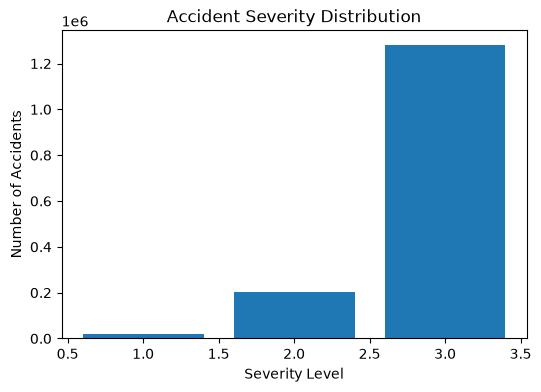

In [41]:
import matplotlib.pyplot as plt

severity_counts = df['Accident_Severity'].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(severity_counts.index, severity_counts.values)

plt.title("Accident Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Number of Accidents")

plt.show()

In [42]:
df=pd.get_dummies(df,columns=['Road_Type'])

In [43]:
df[df.select_dtypes(include=['bool']).columns] = df.select_dtypes(include=['bool']).astype(int)

In [44]:
df.head()

,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Speed_limit,...,Carriageway_Hazards_Involvement with previous accident,Carriageway_Hazards_None,Carriageway_Hazards_Other object in carriageway,Carriageway_Hazards_Pedestrian in carriageway (not injured),Road_Type_Dual carriageway,Road_Type_One way street,Road_Type_Roundabout,Road_Type_Single carriageway,Road_Type_Slip road,Road_Type_Unknown
0,-0.191170,51.489096,1,2,1,3,12,3,3218,30,...,0,1,0,0,0,0,0,1,0,0
1,-0.211708,51.520075,1,3,1,4,12,4,450,30,...,0,1,0,0,1,0,0,0,0,0
2,-0.206458,51.525301,1,3,2,5,12,5,0,30,...,0,1,0,0,0,0,0,1,0,0
3,-0.173862,51.482442,1,3,1,6,12,3,3220,30,...,0,1,0,0,0,0,0,1,0,0
4,-0.156618,51.495752,1,3,1,2,12,6,0,30,...,0,1,0,0,0,0,0,1,0,0


In [45]:
df['Did_Police_Officer_Attend_Scene_of_Accident'].value_counts()

Did_Police_Officer_Attend_Scene_of_Accident
Yes    1218803
No      285246
Name: count, dtype: int64

In [46]:
df['Did_Police_Officer_Attend_Scene_of_Accident'] = df['Did_Police_Officer_Attend_Scene_of_Accident'].map({'Yes': 1, 'No': 0})

In [47]:
X=df.drop(['Accident_Severity'],axis=1)
y=df['Accident_Severity']

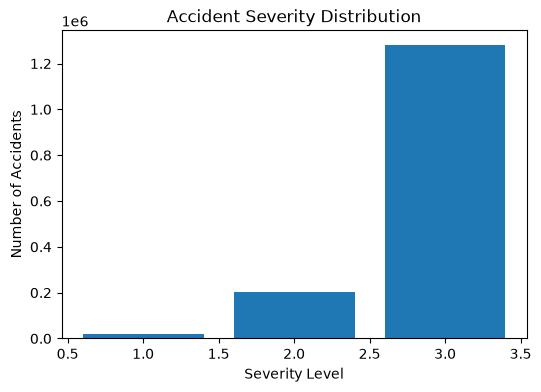

In [48]:
import matplotlib.pyplot as plt

severity_counts = df['Accident_Severity'].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(severity_counts.index, severity_counts.values)

plt.title("Accident Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Number of Accidents")

plt.show()

In [49]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X, y)


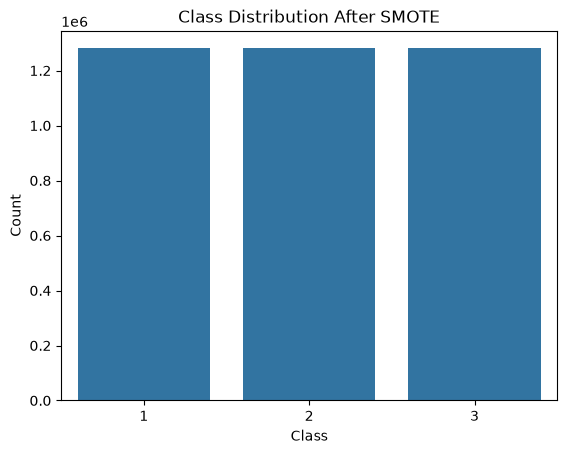

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_resampled)

plt.title('Class Distribution After SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [51]:
import pandas as pd

print("Before SMOTE:")
print(y.value_counts())

print("\nAfter SMOTE:")
print(y_resampled.value_counts())

Before SMOTE:
Accident_Severity
3    1280120
2     204488
1      19441
Name: count, dtype: int64

After SMOTE:
Accident_Severity
2    1280120
3    1280120
1    1280120
Name: count, dtype: int64


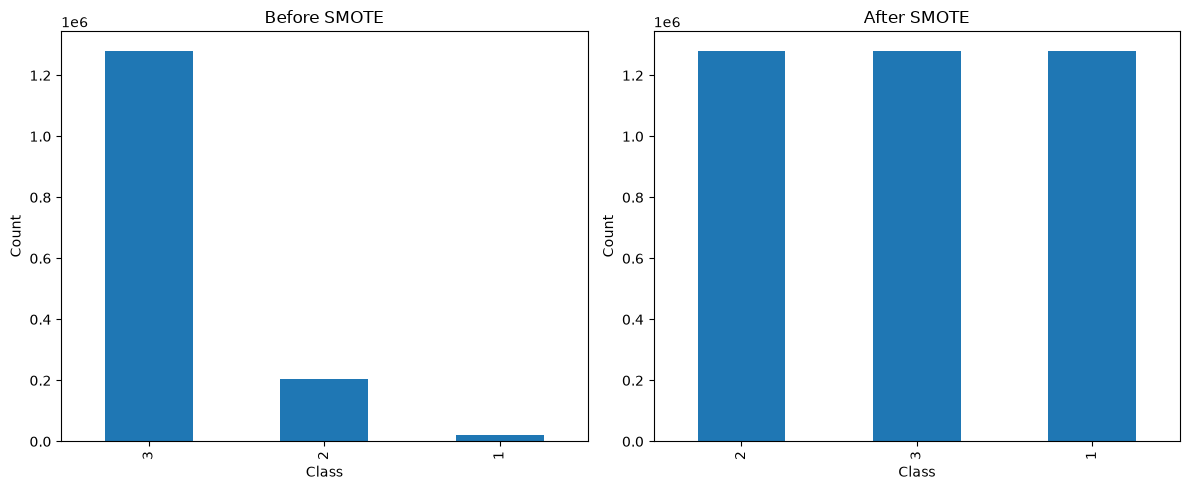

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y.value_counts().plot(kind='bar', ax=axes[0], title='Before SMOTE')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

y_resampled.value_counts().plot(kind='bar', ax=axes[1], title='After SMOTE')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [53]:
print(y_resampled.value_counts())

Accident_Severity
2    1280120
3    1280120
1    1280120
Name: count, dtype: int64


In [54]:
X_train,X_test,y_train,y_test=train_test_split(X_resampled,y_resampled,random_state=42,test_size=0.2)

In [55]:
dtc=DecisionTreeClassifier(class_weight='balanced')

In [56]:
dtc.fit(X_train,y_train)

,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But

In [57]:
y_pred=dtc.predict(X_test)

In [58]:
from sklearn.metrics import accuracy_score,recall_score,f1_score

In [59]:
accuracy_score(y_test,y_pred)

0.8674277932277182